Certificate fingerprint: AB:5A:80:02:8A:E6:14:53:78:40:58:BD:27:95:D5:E3:67:14:D1:E8:65:5D:40:89:64:44:75:AE:60:3F:8D:C0
Certificate checksum (base64): q1qAAormFFN4QFi9J5XV42cU0ehlXUCJZER1rmA/jcA=

Comparison:
APK checksum:         sGi5T37UfnHX2H/B4ZC8Dj9IOKpLVgrJP9wsn4MvHng=
Certificate checksum: q1qAAormFFN4QFi9J5XV42cU0ehlXUCJZER1rmA/jcA=
Are they the same?    False

Certificate-based Payload JSON:
{"android.app.extra.PROVISIONING_DEVICE_ADMIN_COMPONENT_NAME": "com.odensecurewave/com.odensecurewave.AppDeviceAdminReceiver", "android.app.extra.PROVISIONING_DEVICE_ADMIN_PACKAGE_DOWNLOAD_LOCATION": "https://github.com/syedmoazam/OdenSecureWave/releases/download/v1.0.0/app-release.apk", "android.app.extra.PROVISIONING_DEVICE_ADMIN_SIGNATURE_CHECKSUM": "q1qAAormFFN4QFi9J5XV42cU0ehlXUCJZER1rmA/jcA=", "android.app.extra.PROVISIONING_LEAVE_ALL_SYSTEM_APPS_ENABLED": true}

Payload size: 472 characters

Certificate-based QR code saved as 'provisioning_qr_cert.png'
QR code version: 17


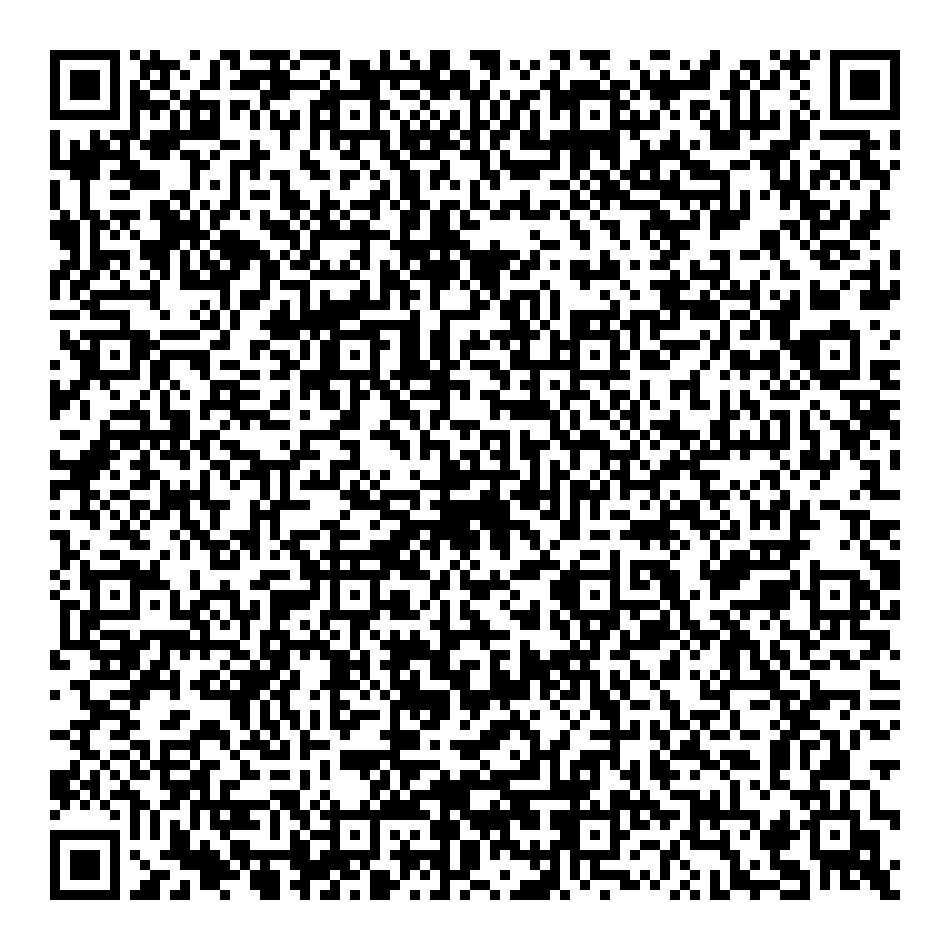

In [3]:
# QR Code with Certificate Fingerprint (Alternative to APK checksum)
import qrcode
import json
import base64

# Certificate SHA-256 fingerprint from the keystore
cert_fingerprint = "AB:5A:80:02:8A:E6:14:53:78:40:58:BD:27:95:D5:E3:67:14:D1:E8:65:5D:40:89:64:44:75:AE:60:3F:8D:C0"

# Convert fingerprint to base64 (remove colons, convert hex to bytes, then base64)
cert_bytes = bytes.fromhex(cert_fingerprint.replace(":", ""))
cert_checksum = base64.b64encode(cert_bytes).decode('utf-8')

print(f"Certificate fingerprint: {cert_fingerprint}")
print(f"Certificate checksum (base64): {cert_checksum}")

# Comparison with APK checksum
apk_checksum = "sGi5T37UfnHX2H/B4ZC8Dj9IOKpLVgrJP9wsn4MvHng="
print(f"\nComparison:")
print(f"APK checksum:         {apk_checksum}")
print(f"Certificate checksum: {cert_checksum}")
print(f"Are they the same?    {apk_checksum == cert_checksum}")

# Payload with certificate fingerprint instead of APK checksum
cert_payload = {
    "android.app.extra.PROVISIONING_DEVICE_ADMIN_COMPONENT_NAME": "com.odensecurewave/com.odensecurewave.AppDeviceAdminReceiver",
    "android.app.extra.PROVISIONING_DEVICE_ADMIN_PACKAGE_DOWNLOAD_LOCATION": "https://github.com/syedmoazam/OdenSecureWave/releases/download/v1.0.0/app-release.apk",
    "android.app.extra.PROVISIONING_DEVICE_ADMIN_SIGNATURE_CHECKSUM": cert_checksum,
    "android.app.extra.PROVISIONING_LEAVE_ALL_SYSTEM_APPS_ENABLED": True
}

# Convert to JSON
cert_json = json.dumps(cert_payload)
print(f"\nCertificate-based Payload JSON:")
print(cert_json)
print(f"\nPayload size: {len(cert_json)} characters")

# Generate QR code with certificate fingerprint
qr_cert = qrcode.QRCode(version=2, box_size=10, border=5)
qr_cert.add_data(cert_json)
qr_cert.make(fit=True)

# Save certificate-based QR code
img_cert = qr_cert.make_image(fill="black", back_color="white")
img_cert.save("provisioning_qr_cert.png")
print(f"\nCertificate-based QR code saved as 'provisioning_qr_cert.png'")
print(f"QR code version: {qr_cert.version}")
img_cert

=== TROUBLESHOOTING QR CODE FORMATS ===
Since you're getting immediate errors, let's try different approaches:

1. Ultra-minimal payload (no optional fields):
   Size: 402 characters
   JSON: {"android.app.extra.PROVISIONING_DEVICE_ADMIN_COMPONENT_NAME": "com.odensecurewave/com.odensecurewave.AppDeviceAdminReceiver", "android.app.extra.PROVISIONING_DEVICE_ADMIN_PACKAGE_DOWNLOAD_LOCATION": "https://github.com/syedmoazam/OdenSecureWave/releases/download/v1.0.0/app-release.apk", "android.app.extra.PROVISIONING_DEVICE_ADMIN_SIGNATURE_CHECKSUM": "sGi5T37UfnHX2H/B4ZC8Dj9IOKpLVgrJP9wsn4MvHng="}
   QR code saved as 'provisioning_qr_ultra.png'

2. No checksum payload (let Android verify internally):
   Size: 288 characters
   JSON: {"android.app.extra.PROVISIONING_DEVICE_ADMIN_COMPONENT_NAME": "com.odensecurewave/com.odensecurewave.AppDeviceAdminReceiver", "android.app.extra.PROVISIONING_DEVICE_ADMIN_PACKAGE_DOWNLOAD_LOCATION": "https://github.com/syedmoazam/OdenSecureWave/releases/download/v1.

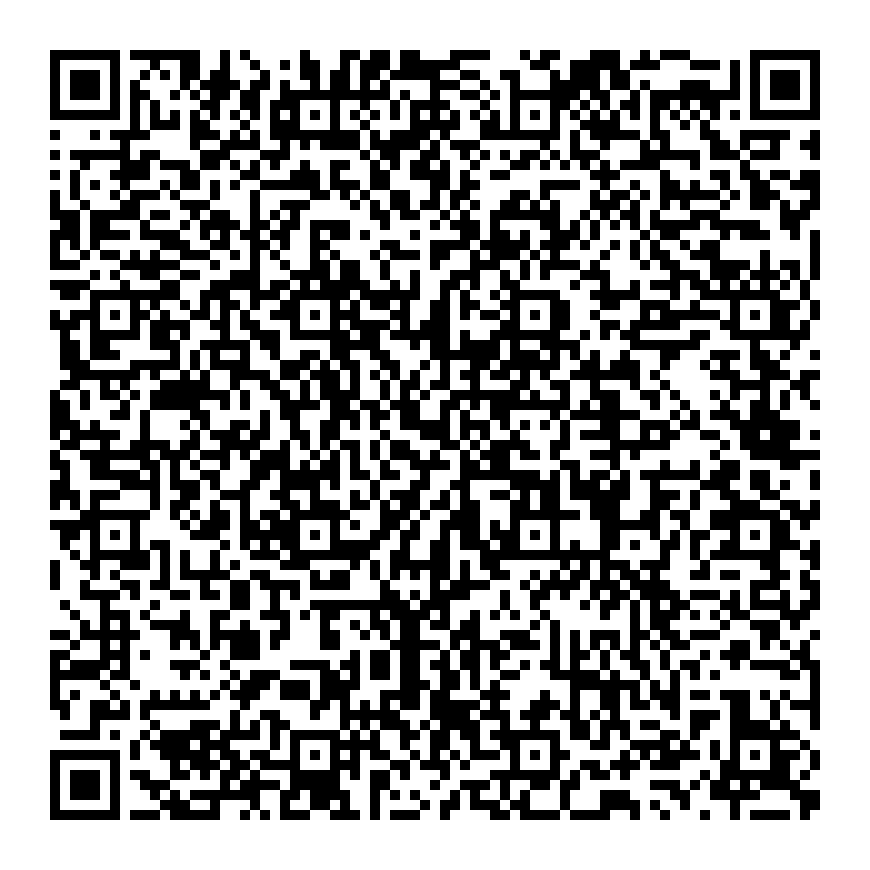

In [4]:
# Alternative QR Code Formats for Troubleshooting
import qrcode
import json

print("=== TROUBLESHOOTING QR CODE FORMATS ===")
print("Since you're getting immediate errors, let's try different approaches:")

# 1. Ultra-minimal payload (absolute minimum)
ultra_minimal = {
    "android.app.extra.PROVISIONING_DEVICE_ADMIN_COMPONENT_NAME": "com.odensecurewave/com.odensecurewave.AppDeviceAdminReceiver",
    "android.app.extra.PROVISIONING_DEVICE_ADMIN_PACKAGE_DOWNLOAD_LOCATION": "https://github.com/syedmoazam/OdenSecureWave/releases/download/v1.0.0/app-release.apk",
    "android.app.extra.PROVISIONING_DEVICE_ADMIN_SIGNATURE_CHECKSUM": "sGi5T37UfnHX2H/B4ZC8Dj9IOKpLVgrJP9wsn4MvHng="
}

ultra_json = json.dumps(ultra_minimal)
print(f"\n1. Ultra-minimal payload (no optional fields):")
print(f"   Size: {len(ultra_json)} characters")
print(f"   JSON: {ultra_json}")

# Generate ultra-minimal QR code
qr_ultra = qrcode.QRCode(version=1, box_size=10, border=5)
qr_ultra.add_data(ultra_json)
qr_ultra.make(fit=True)

img_ultra = qr_ultra.make_image(fill="black", back_color="white")
img_ultra.save("provisioning_qr_ultra.png")
print(f"   QR code saved as 'provisioning_qr_ultra.png'")

# 2. Without checksum (for testing - Android might download and verify internally)
no_checksum = {
    "android.app.extra.PROVISIONING_DEVICE_ADMIN_COMPONENT_NAME": "com.odensecurewave/com.odensecurewave.AppDeviceAdminReceiver",
    "android.app.extra.PROVISIONING_DEVICE_ADMIN_PACKAGE_DOWNLOAD_LOCATION": "https://github.com/syedmoazam/OdenSecureWave/releases/download/v1.0.0/app-release.apk"
}

no_checksum_json = json.dumps(no_checksum)
print(f"\n2. No checksum payload (let Android verify internally):")
print(f"   Size: {len(no_checksum_json)} characters")
print(f"   JSON: {no_checksum_json}")

# Generate no-checksum QR code
qr_no_checksum = qrcode.QRCode(version=1, box_size=10, border=5)
qr_no_checksum.add_data(no_checksum_json)
qr_no_checksum.make(fit=True)

img_no_checksum = qr_no_checksum.make_image(fill="black", back_color="white")
img_no_checksum.save("provisioning_qr_no_checksum.png")
print(f"   QR code saved as 'provisioning_qr_no_checksum.png'")

# 3. Check if component name format is correct
print(f"\n3. Component name verification:")
print(f"   Current: com.odensecurewave/com.odensecurewave.AppDeviceAdminReceiver")
print(f"   Package: com.odensecurewave")
print(f"   Class: com.odensecurewave.AppDeviceAdminReceiver")
print(f"   Format: [package]/[full.class.name] ✓")

print(f"\n=== TESTING RECOMMENDATION ===")
print(f"Try in this order:")
print(f"1. Ultra-minimal QR code (provisioning_qr_ultra.png)")
print(f"2. No checksum QR code (provisioning_qr_no_checksum.png)")
print(f"3. Original minimal QR code (provisioning_qr_minimal.png)")
print(f"4. Certificate QR code (provisioning_qr_cert.png)")

# Display ultra-minimal QR code
img_ultra

# Immediate QR Code Error Diagnosis

## Why "Can't setup IT admin" happens immediately after scanning:

### 1. **QR Code Format Issues**
- **Invalid JSON syntax**: Check for syntax errors in the payload
- **Missing required fields**: Android expects specific parameters
- **Wrong parameter names**: Typos in field names cause immediate rejection
- **Encoding issues**: Special characters or encoding problems

### 2. **Component Name Issues**
- **Package mismatch**: Component name doesn't match your APK package
- **Class not found**: DeviceAdminReceiver not properly declared in manifest
- **Permission issues**: Missing device admin permissions

### 3. **URL/Download Issues**
- **Invalid URL**: APK download URL is malformed or inaccessible
- **Network restrictions**: Device can't reach GitHub during setup
- **HTTPS issues**: SSL certificate problems

### 4. **Android Version Compatibility**
- **Old Android version**: QR provisioning requires Android 7.0+ (API 24+)
- **Custom ROM**: Some custom ROMs have broken provisioning
- **Manufacturer restrictions**: Some OEMs disable QR provisioning

### 5. **Device State Issues**
- **Not properly factory reset**: Device still has previous configuration
- **Wrong timing**: QR code scanned at wrong point in setup
- **Multiple attempts**: Previous failed attempts left device in bad state

## Troubleshooting Steps:

### **Step 1: Try the No-Checksum QR Code**
- File: `provisioning_qr_no_checksum.png`
- This eliminates signature verification issues
- Android will attempt to download and verify the APK itself

### **Step 2: Verify Component Name**
Double-check your AndroidManifest.xml:
```xml
<receiver android:name=".AppDeviceAdminReceiver"
          android:permission="android.permission.BIND_DEVICE_ADMIN"
          android:exported="true">
```

### **Step 3: Check Device Compatibility**
- What Android version is your device?
- What device model/manufacturer?
- Is it a custom ROM or stock Android?

### **Step 4: Alternative Setup Method**
If QR codes keep failing, try ADB method:
```bash
# After factory reset but before completing setup
adb shell dpm set-device-owner com.odensecurewave/.AppDeviceAdminReceiver
```

### **Step 5: Monitor Logs**
During QR code scan, monitor device logs:
```bash
adb logcat | grep -i "provision\|deviceadmin\|qr"
```

## Next Steps:
1. **Try the no-checksum QR code first** - this is the most likely to work
2. **If that fails**, the issue is likely with your component name or device compatibility
3. **Check your AndroidManifest.xml** to ensure the receiver is properly declared
4. **Test with ADB method** as a fallback